# Watermark Predictor Benchmark Results

Plots for `results/results.csv`. Hue is always the `predictor`. VLDB/SIGMOD-style figures.

Run `pip install pandas matplotlib seaborn` if not already available.

## Reading the `trace` labels

Each trace is a synthetic watermark stream — a sequence of `(watermark value, wall-clock arrival)` **samples**. A label combines a base regime with optional noise:

**Base regime** (the clean signal — deterministic, no randomness):
- `ConstantRate(r)` — single phase, watermark advances at a fixed rate `r` the whole time.
- `RateChange(1->4)` — rate steps **up** at a phase boundary (1.0 → 4.0).
- `Stall(2.0->0)` — the watermark **holds flat** (rate 0) while wall-clock keeps advancing, then resumes. Models an idle source / event-time gap.
- `CatchUp(2.0->8.0)` — a short stall followed by a **fast burst** (rate 8.0) that drains the backlog before settling. Breaks predictors that carried the stalled rate forward.

**`+N samples`** — appears on traces with a regime change (`RateChange`, `Stall`, `CatchUp`). `N` = how many samples the predictor observes *after* the onset of the change before it must predict. It's the **convergence horizon**: `+2` = predict almost immediately (predictor hasn't caught up yet), `+50` = lots of time to re-adapt. `ConstantRate` is steady-state, so it never carries this tag.

**Noise tags** — perturb only the *wall-clock arrival* of each sample; the watermark values themselves are untouched:
- `clean` — no noise.
- `mild/heavy jitter (sd=σ)` — zero-mean Gaussian jitter on arrivals (σ = 10 / 30). Symmetric.
- `X% stragglers` — a fraction `X` of samples get an extra one-sided delay (heavy positive tail), on top of light jitter.

Tags compose: `RateChange(1->4) +20 + heavy jitter` = a rate step, 20 post-change samples observed, *and* noisy arrivals. `ConstantRate(2.0) + 10% stragglers` has only the noise axis (no `+N`, since there's no rate change to converge to).

In [1]:
import re
from pathlib import Path

import pandas as pd

# Error metrics in results.csv:
#   mae      = Mean Absolute Error            (avg |predicted - actual|, in events)
#   rmse     = Root Mean Squared Error        (penalizes large misses more than mae)
#   mape_pct = Mean Absolute Percentage Error (avg |error| / actual, in %)
#   max_err  = worst single absolute error    (in events)

df = pd.read_csv(Path('results') / 'results.csv')

# --- unit conversions ---------------------------------------------------
# mean_ms/min_ms are wall-clock for `reps` runs over all predicts; keep ms but add seconds.
df['mean_s'] = df['mean_ms'] / 1_000.0
df['min_s'] = df['min_ms'] / 1_000.0
df['us_per_predict'] = df['ns_per_predict'] / 1_000.0
df['predicts_per_us'] = 1_000.0 / df['ns_per_predict']

# --- parse the trace string into structured scenario columns ------------
def family(t):
    if t.startswith('ConstantRate'):
        return 'ConstantRate'
    if t.startswith('RateChange'):
        return 'RateChange'
    if t.startswith('Stall'):
        return 'Stall'
    if t.startswith('CatchUp'):
        return 'CatchUp'
    return 'Other'

def noise(t):
    if 'heavy jitter' in t:
        return 'heavy jitter'
    if 'mild jitter' in t:
        return 'mild jitter'
    if 'heavy stragglers' in t:
        return 'heavy stragglers'
    if 'stragglers' in t:
        return 'stragglers'
    return 'clean'

def grab(pattern, t, cast=float):
    m = re.search(pattern, t)
    return cast(m.group(1)) if m else None

df['family'] = df['trace'].map(family)
df['noise'] = df['trace'].map(noise)
# samples observed after a regime change (recovery / adaptation horizon)
df['samples_after'] = df['trace'].apply(lambda t: grab(r'\+(\d+) samples', t, int))
# straggler fraction in percent
df['straggler_pct'] = df['trace'].apply(lambda t: grab(r'(\d+)% ', t, int))
# jitter standard deviation
df['jitter_sd'] = df['trace'].apply(lambda t: grab(r'sd=(\d+)', t, int))

PREDICTOR_ORDER = sorted(df['predictor'].unique())
print(df.shape, '|', list(df['predictor'].unique()))
df.head()

(148, 20) | ['EWMA(alpha=0.3)', 'EWMA(alpha=0.5)', 'EWMA(alpha=1.0)', 'Kalman(config1)', 'Kalman(config2)', 'RobustAdaptiveKalman']


,trace,predictor,samples,mae,rmse,mape_pct,max_err,reps,mean_ms,min_ms,ns_per_predict,mean_s,min_s,us_per_predict,predicts_per_us,family,noise,samples_after,straggler_pct,jitter_sd
0,ConstantRate(2.0) clean,EWMA(alpha=0.3),4,0.0,0.0,0.00,0.0,5,450.33,449.97,4.50,0.45033,0.44997,0.00450,222.222222,ConstantRate,clean,NaN,NaN,NaN
1,ConstantRate(2.0) clean,EWMA(alpha=0.5),4,0.0,0.0,0.00,0.0,5,450.05,449.92,4.50,0.45005,0.44992,0.00450,222.222222,ConstantRate,clean,NaN,NaN,NaN
2,ConstantRate(2.0) clean,EWMA(alpha=1.0),4,0.0,0.0,0.00,0.0,5,450.00,449.92,4.50,0.45000,0.44992,0.00450,222.222222,ConstantRate,clean,NaN,NaN,NaN
3,ConstantRate(2.0) clean,Kalman(config1),4,0.0,0.0,0.00,0.0,5,460.83,460.68,4.61,0.46083,0.46068,0.00461,216.919740,ConstantRate,clean,NaN,NaN,NaN
4,ConstantRate(2.0) clean,Kalman(config2),4,1.0,1.0,0.01,1.0,5,460.80,460.73,4.61,0.46080,0.46073,0.00461,216.919740,ConstantRate,clean,NaN,NaN,NaN


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# VLDB / SIGMOD camera-ready style: serif, compact, no chartjunk.
sns.set_theme(context='paper', style='whitegrid', font='serif')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'axes.titleweight': 'bold',
    'legend.fontsize': 9,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
})
# tab10 = the most-separated qualitative hues; the muted 'colorblind' set washed out the
# same-family predictors (3x EWMA, 2x Kalman, Robust). MARKERS adds a second visual channel so
# the line plots stay readable where two hues sit close — pass them via style= in lineplot.
PALETTE = dict(zip(PREDICTOR_ORDER, sns.color_palette('tab10', len(PREDICTOR_ORDER))))
MARKERS = dict(zip(PREDICTOR_ORDER, ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>'][:len(PREDICTOR_ORDER)]))

def legend_below(ax, ncol=None):
    ax.legend(title='predictor', loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=ncol or len(PREDICTOR_ORDER))
print('style ready, palette:', PALETTE)

style ready, palette: {'EWMA(alpha=0.3)': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'EWMA(alpha=0.5)': (1.0, 0.4980392156862745, 0.054901960784313725), 'EWMA(alpha=1.0)': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), 'Kalman(config1)': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), 'Kalman(config2)': (0.5803921568627451, 0.403921568627451, 0.7411764705882353), 'RobustAdaptiveKalman': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)}


## 0. Scenario shapes
The raw signal each predictor must extrapolate: watermark **event-time** against **wall-clock** for every clean base scenario. Slope = advancement rate, flat = stall, steep = catch-up burst. Exported by the benchmark binary to `results/traces.csv` (single source of truth — same definitions the accuracy runs use).

In [ ]:
traces = pd.read_csv(Path('results') / 'traces.csv')
scenarios = list(traces['scenario'].unique())
ncol = 2
nrow = -(-len(scenarios) // ncol)  # ceil
fig, axes = plt.subplots(nrow, ncol, figsize=(9, 3.0 * nrow), sharex=True)
for ax, scen in zip(axes.flat, scenarios):
    g = traces[traces['scenario'] == scen]
    ax.plot(g['wall_clock'], g['event_time'], lw=1.6, color='C0')
    ax.set_title(scen)
    ax.set_xlabel('wall-clock')
    ax.set_ylabel('watermark (event-time)')
for ax in axes.flat[len(scenarios):]:
    ax.set_visible(False)
fig.suptitle('Scenario shapes: watermark event-time vs wall-clock')
fig.tight_layout()
plt.show()

## 1. Accuracy per scenario family
Mean error (MAE) and relative error (MAPE) aggregated by scenario family — the headline "who is more accurate" view.

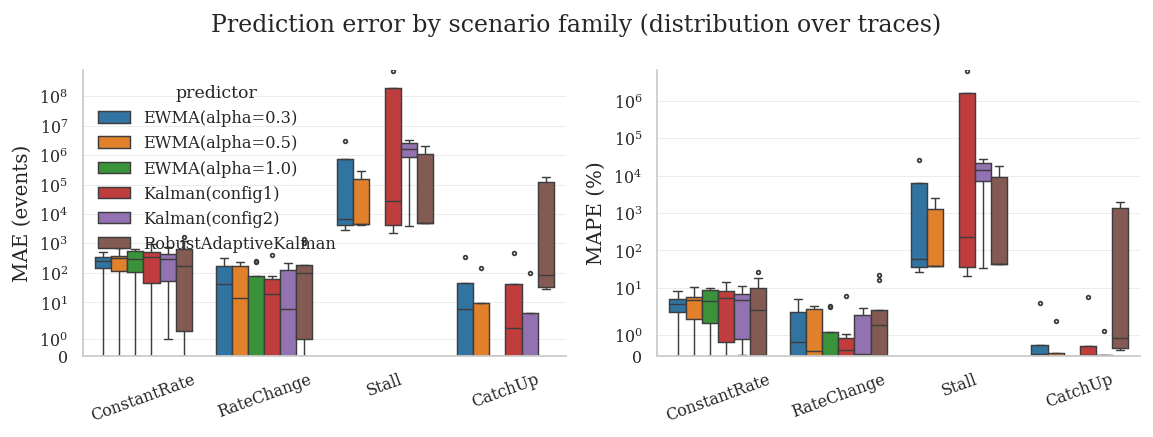

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharex=True)
for ax, (metric, label) in zip(axes, [('mae', 'MAE (events)'), ('mape_pct', 'MAPE (%)')]):
    sns.boxplot(df, x='family', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                palette=PALETTE, fliersize=2, linewidth=0.8, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    # symlog: stall/catch-up errors are orders of magnitude above the clean families; linear hides them.
    ax.set_yscale('symlog')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=20)
    ax.get_legend().remove()
axes[0].legend(title='predictor', loc='upper left', ncol=1)
fig.suptitle('Prediction error by scenario family (distribution over traces)')
fig.tight_layout()
plt.show()

## 2. Convergence after a rate change
How fast does each predictor recover once the rate jumps `1 -> 4`? Lower MAE at fewer post-change samples = faster convergence.

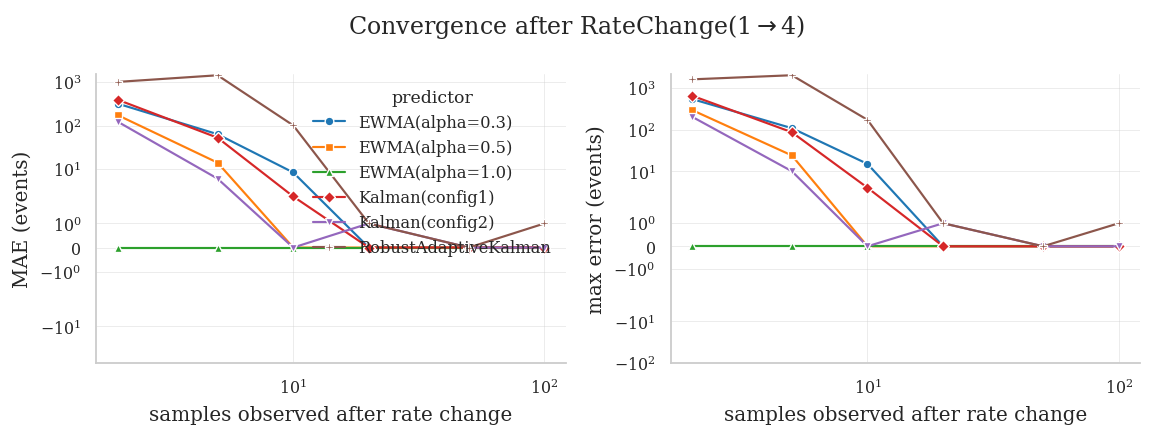

In [4]:
conv = df[(df['family'] == 'RateChange') & (df['noise'] == 'clean') & df['samples_after'].notna()]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, (metric, label) in zip(axes, [('mae', 'MAE (events)'), ('max_err', 'max error (events)')]):
    sns.lineplot(conv, x='samples_after', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                 style='predictor', markers=MARKERS, dashes=False, palette=PALETTE, ax=ax)
    ax.set_xscale('log')
    ax.set_yscale('symlog')  # error spans orders of magnitude as the predictor converges
    ax.set_xlabel('samples observed after rate change')
    ax.set_ylabel(label)
    ax.get_legend().remove()
axes[0].legend(title='predictor', loc='upper right')
fig.suptitle('Convergence after RateChange(1$\\rightarrow$4)')
fig.tight_layout()
plt.show()

## 2b. Adaptation after a stall / catch-up
The watermark-specific stress tests. **Stall**: rate drops to 0 (idle source) — does the predictor stop extrapolating forward? **CatchUp**: a stall followed by a rate-8 burst — does it track the surge, or lag carrying the stalled rate? Lower error at fewer post-onset samples = faster adaptation.

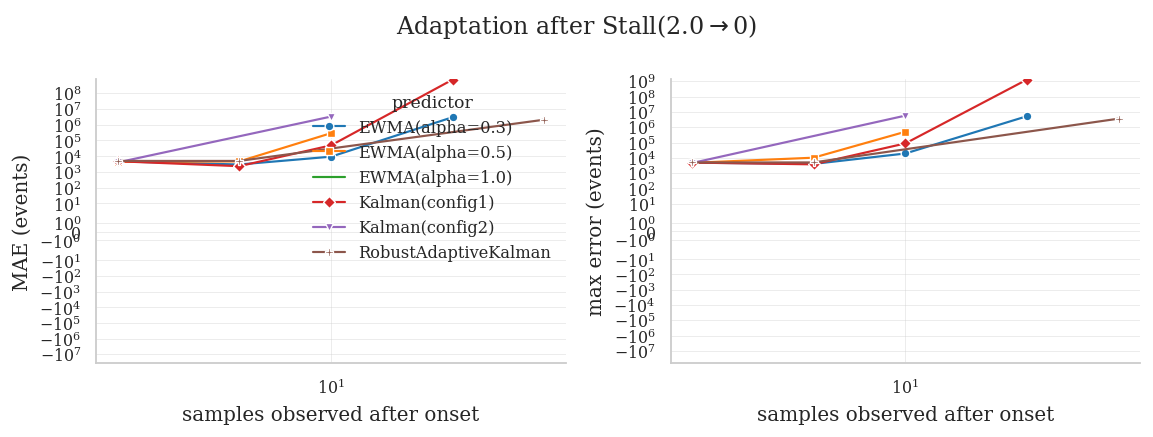

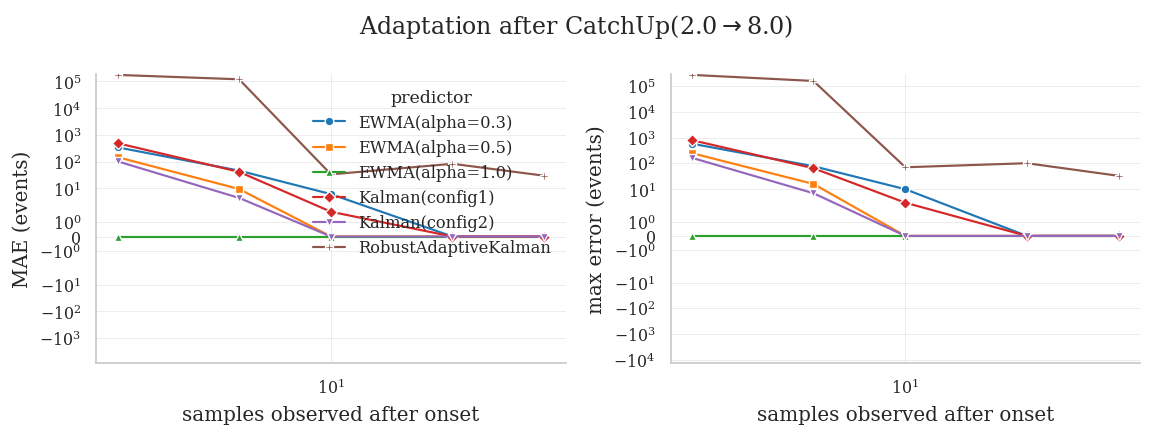

In [5]:
for fam, title in [('Stall', 'Stall(2.0$\\rightarrow$0)'), ('CatchUp', 'CatchUp(2.0$\\rightarrow$8.0)')]:
    sub = df[(df['family'] == fam) & (df['noise'] == 'clean') & df['samples_after'].notna()]
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    for ax, (metric, label) in zip(axes, [('mae', 'MAE (events)'), ('max_err', 'max error (events)')]):
        sns.lineplot(sub, x='samples_after', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                     style='predictor', markers=MARKERS, dashes=False, palette=PALETTE, ax=ax)
        ax.set_xscale('log')
        ax.set_yscale('symlog')  # stalled-rate extrapolation blows the error up by orders of magnitude
        ax.set_xlabel('samples observed after onset')
        ax.set_ylabel(label)
        ax.get_legend().remove()
    axes[0].legend(title='predictor', loc='upper right')
    fig.suptitle(f'Adaptation after {title}')
    fig.tight_layout()
    plt.show()

## 3. Robustness to stragglers
Error as the fraction of heavy stragglers grows (ConstantRate(2.0) base). Tests how each predictor tolerates delayed/late samples.

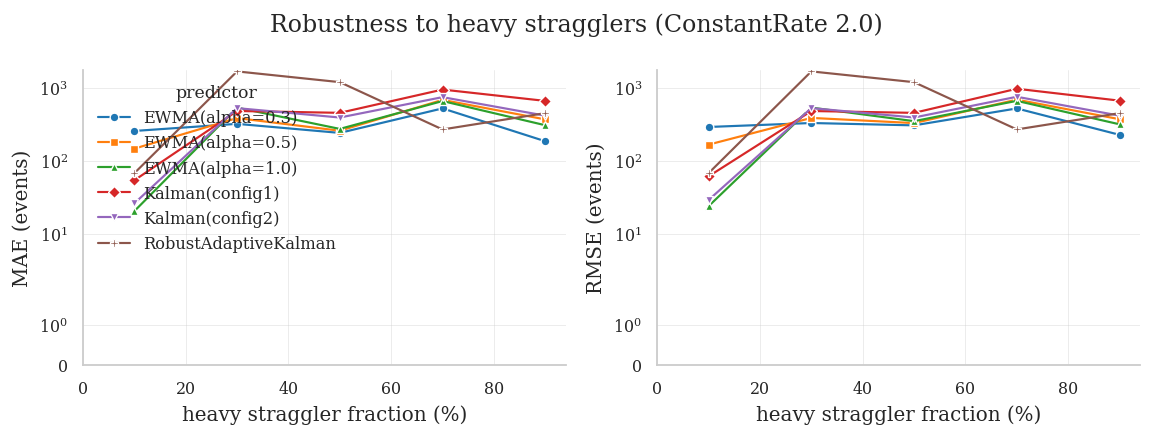

In [6]:
strag = df[df['straggler_pct'].notna() & (df['family'] == 'ConstantRate')].copy()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
for ax, (metric, label) in zip(axes, [('mae', 'MAE (events)'), ('rmse', 'RMSE (events)')]):
    sns.lineplot(strag, x='straggler_pct', y=metric, hue='predictor', hue_order=PREDICTOR_ORDER,
                 style='predictor', markers=MARKERS, dashes=False, palette=PALETTE, ax=ax)
    ax.set_xlabel('heavy straggler fraction (%)')
    ax.set_ylabel(label)
    ax.set_xlim(left=0)
    ax.set_yscale('symlog')  # error grows steeply with straggler fraction; log keeps the low end legible
    ax.set_ylim(bottom=0)
    ax.get_legend().remove()
axes[0].legend(title='predictor', loc='upper left')
fig.suptitle('Robustness to heavy stragglers (ConstantRate 2.0)')
fig.tight_layout()
plt.show()

## 4. Sensitivity to jitter
Error grouped by jitter level (clean / mild sd=10 / heavy sd=30), across the traces that carry jitter.

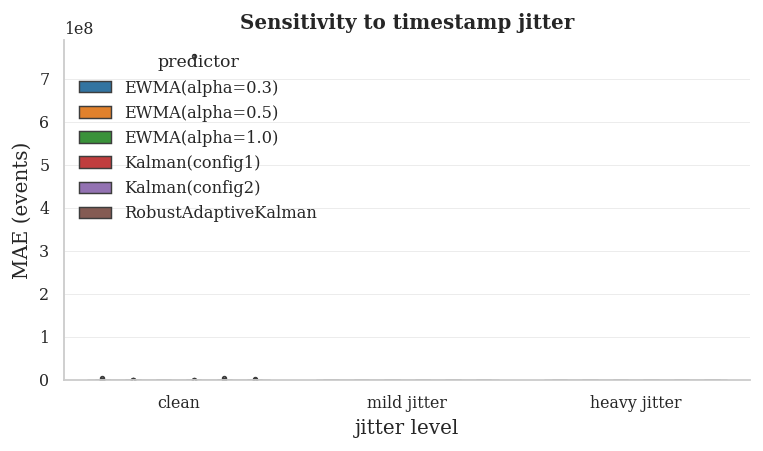

In [7]:
jit_order = ['clean', 'mild jitter', 'heavy jitter']
jit = df[df['noise'].isin(jit_order)].copy()
jit['noise'] = pd.Categorical(jit['noise'], categories=jit_order, ordered=True)
fig, ax = plt.subplots(figsize=(6, 3.6))
sns.boxplot(jit, x='noise', y='mae', hue='predictor', hue_order=PREDICTOR_ORDER,
            palette=PALETTE, fliersize=2, linewidth=0.8, ax=ax)
ax.set_xlabel('jitter level')
ax.set_ylabel('MAE (events)')
ax.set_ylim(bottom=-50)
ax.set_title('Sensitivity to timestamp jitter')
ax.legend(title='predictor', loc='upper left')
fig.tight_layout()
plt.show()

## 5. Accuracy vs. latency trade-off
Per-predict cost (ns) against achieved error. Cheap *and* accurate is bottom-left. Marker per scenario family.

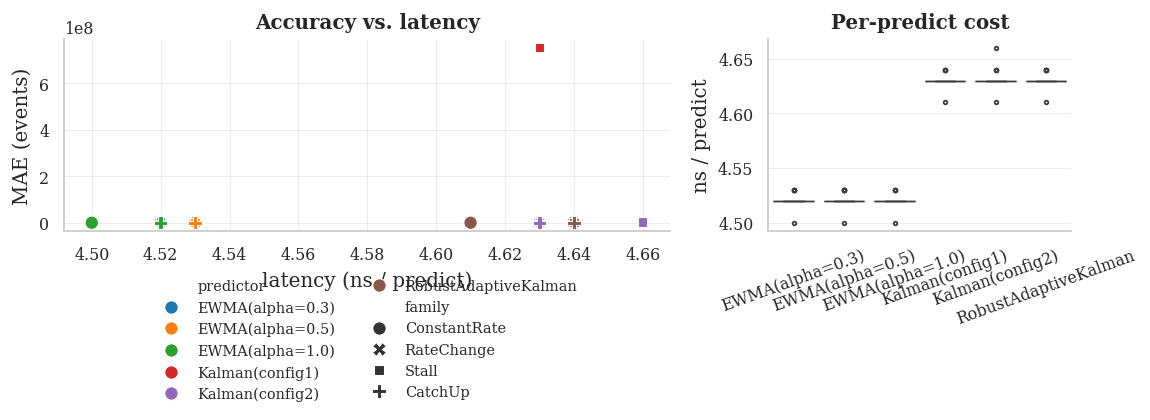

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), gridspec_kw={'width_ratios': [2, 1]})

sns.scatterplot(df, x='ns_per_predict', y='mae', hue='predictor', hue_order=PREDICTOR_ORDER,
                style='family', palette=PALETTE, s=55, ax=axes[0])
axes[0].set_xlabel('latency (ns / predict)')
axes[0].set_ylabel('MAE (events)')
#axes[0].set_xlim(left=0)
#axes[0].set_ylim(bottom=0)
axes[0].set_title('Accuracy vs. latency')
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, fontsize=8)

# per-predict latency is near-constant per predictor -> show the distribution compactly
sns.boxplot(df, x='predictor', y='ns_per_predict', hue='predictor', hue_order=PREDICTOR_ORDER,
            palette=PALETTE, fliersize=2, linewidth=0.8, legend=False, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_ylabel('ns / predict')
#axes[1].set_ylim(bottom=0)
axes[1].set_title('Per-predict cost')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

## 6. Per-trace error heatmap
Full breakdown: every trace × predictor, colored by MAE. The dense "where does each predictor win/lose" view.

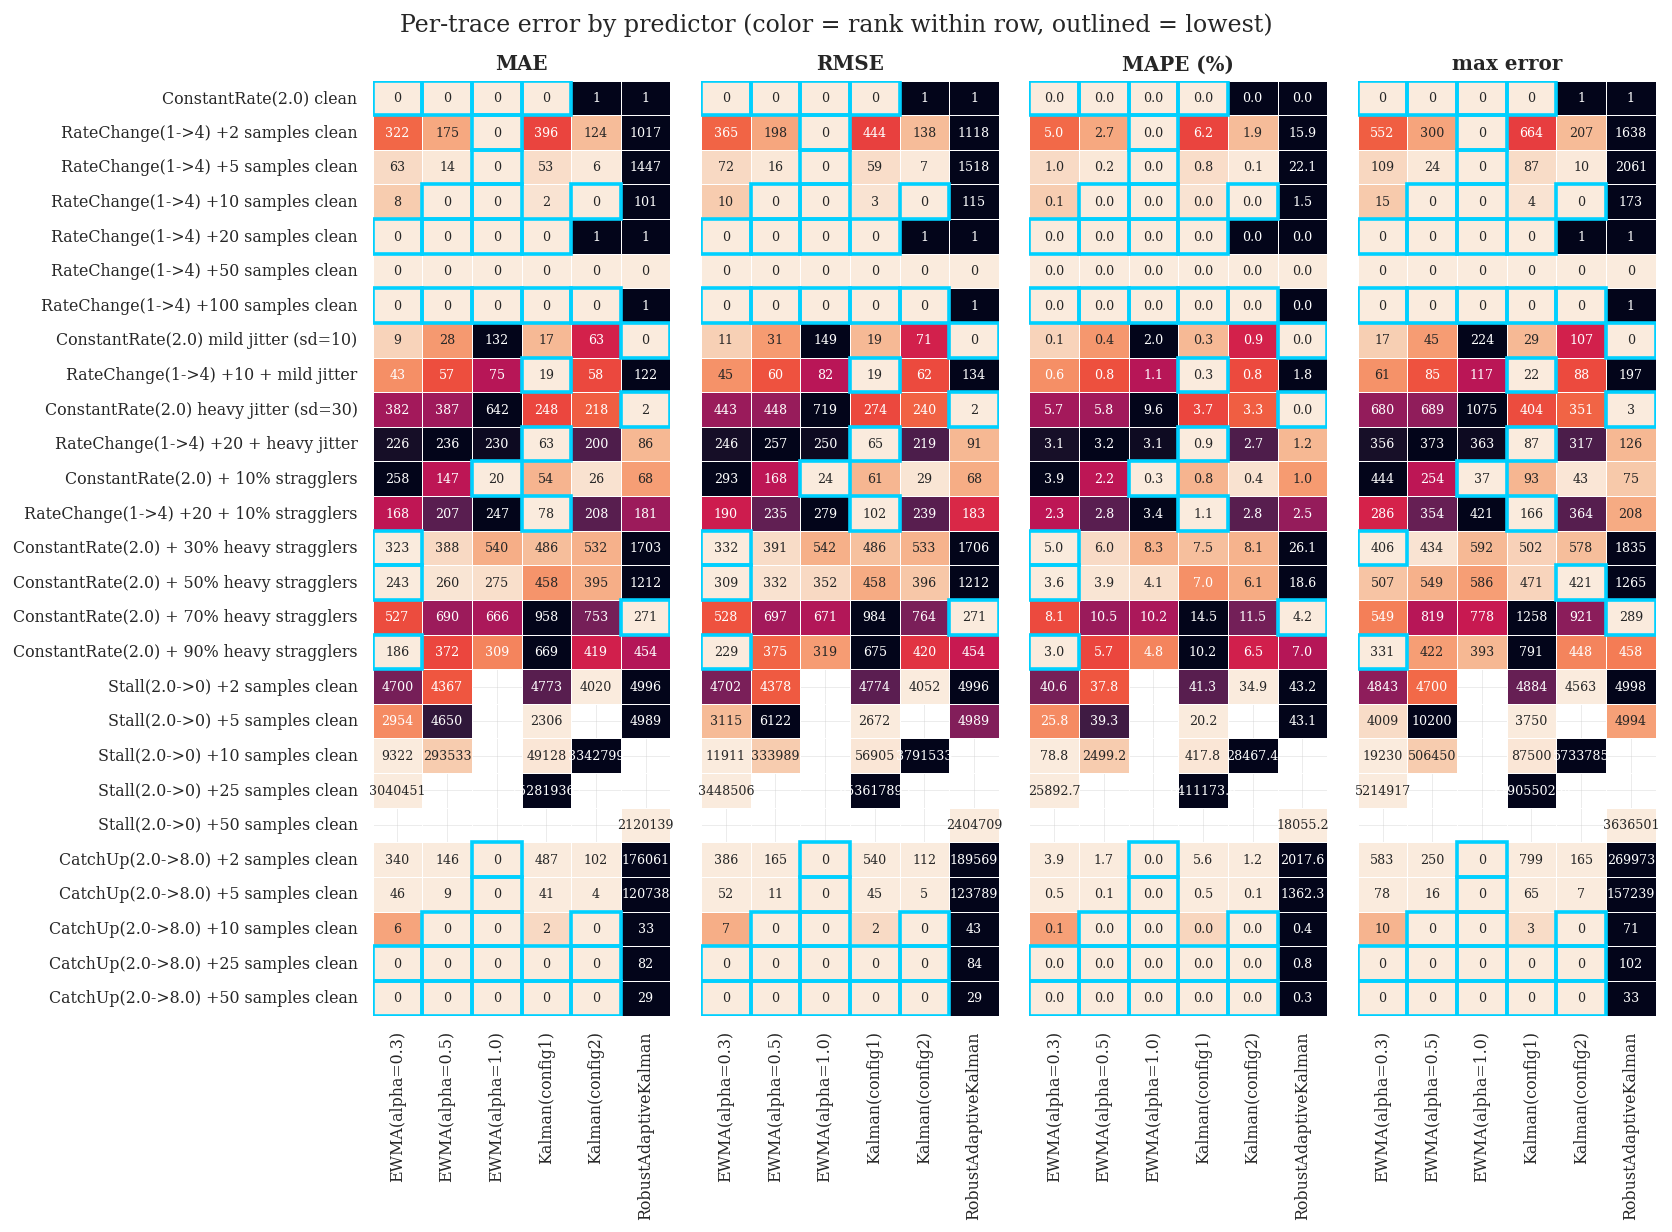

In [9]:
from matplotlib.patches import Rectangle

# same per-trace x predictor heatmap, for every error metric (all lower = better)
# Color is normalized PER ROW (each trace) so a few huge-magnitude traces (stall/catch-up) don't
# flatten every other row to one color. Annotations stay the real values; cyan outlines the best.
METRICS = [('mae', 'MAE', '.0f'), ('rmse', 'RMSE', '.0f'), ('mape_pct', 'MAPE (%)', '.1f'), ('max_err', 'max error', '.0f')]
fig, axes = plt.subplots(1, len(METRICS), figsize=(3.0 * len(METRICS) + 1, 0.32 * df['trace'].nunique() + 1),
                         sharey=True)
for ax, (metric, label, fmt) in zip(axes, METRICS):
    pivot = df.pivot_table(index='trace', columns='predictor', values=metric, sort=False)[PREDICTOR_ORDER]
    span = (pivot.max(axis=1) - pivot.min(axis=1)).replace(0, 1)
    norm = pivot.sub(pivot.min(axis=1), axis=0).div(span, axis=0)  # 0 = best (lowest) .. 1 = worst per row
    sns.heatmap(norm, annot=pivot, fmt=fmt, cmap='rocket_r', linewidths=0.4,
                annot_kws={'fontsize': 7}, cbar=False, vmin=0, vmax=1, ax=ax)
    # outline the best (lowest) predictor(s) per row; skip all-tie rows
    for row, vals in enumerate(pivot.values):
        if vals.min() == vals.max():
            continue
        for col in (vals == vals.min()).nonzero()[0]:
            ax.add_patch(Rectangle((col, row), 1, 1, fill=False, edgecolor='#00d0ff', lw=2.0))
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(label)
fig.suptitle('Per-trace error by predictor (color = rank within row, outlined = lowest)')
fig.tight_layout()
plt.show()